# Keras Push-up Classifier — LSTM
Uses MediaPipe Pose to extract landmarks from video frames, then trains an LSTM
neural network on sequences of 20 consecutive frames.

Feeding sequences instead of single frames lets the model learn the *direction
of movement*, not just a position — so it understands the difference between
going down and coming back up even when the elbow angle looks identical.

**Pipeline:**
1. MediaPipe extracts pose landmarks per frame
2. Only relevant landmarks + computed angles kept (21 features)
3. Frames grouped into sliding windows of 20; transition windows discarded
4. LSTM model trained on the sequences
5. Exported as `.keras`, `.tflite`, and `.onnx`

In [1]:
%pip install mediapipe opencv-python numpy tensorflow scikit-learn kagglehub tf2onnx

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\gusta\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 1 — Setup

In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json
import shutil
import urllib.request
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MODEL_PATH = os.path.join(os.getcwd(), 'pose_landmarker.task')

if not os.path.exists(MODEL_PATH):
    print('Downloading pose landmarker model...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task',
        MODEL_PATH
    )
    print('Done.')
else:
    print(f'Model found: {MODEL_PATH}')

SEQUENCE_LENGTH = 20

RELEVANT_IDX   = [11, 12, 13, 14, 15, 16]
LEFT_SHOULDER, RIGHT_SHOULDER = 11, 12
LEFT_ELBOW,    RIGHT_ELBOW    = 13, 14
LEFT_WRIST,    RIGHT_WRIST    = 15, 16

PUSHUP_CONFIG = {
    'down_elbow_threshold':  90,
    'up_elbow_threshold':   160,
    'visibility_threshold':  0.6,
}

CLASS_NAMES = ['Up (0)', 'Down (1)']

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc  = a - b, c - b
    cosine  = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))

def extract_features(landmarks):
    def get(idx):
        p = landmarks[idx]
        return [p.x, p.y], p.visibility

    sh_l, v1 = get(LEFT_SHOULDER)
    sh_r, v2 = get(RIGHT_SHOULDER)
    el_l, v3 = get(LEFT_ELBOW)
    el_r, v4 = get(RIGHT_ELBOW)
    wr_l, v5 = get(LEFT_WRIST)
    wr_r, v6 = get(RIGHT_WRIST)

    if min(v1, v2, v3, v4, v5, v6) < PUSHUP_CONFIG['visibility_threshold']:
        return -1, None, None

    elbow_l   = calculate_angle(sh_l, el_l, wr_l)
    elbow_r   = calculate_angle(sh_r, el_r, wr_r)
    avg_elbow = (elbow_l + elbow_r) / 2

    coords   = [v for idx in RELEVANT_IDX
                  for v in (landmarks[idx].x, landmarks[idx].y, landmarks[idx].visibility)]
    features = coords + [elbow_l, elbow_r, avg_elbow]

    if avg_elbow < PUSHUP_CONFIG['down_elbow_threshold']:
        label = 1
    elif avg_elbow > PUSHUP_CONFIG['up_elbow_threshold']:
        label = 0
    else:
        label = -1

    return label, features, avg_elbow

FEATURE_SIZE = len(RELEVANT_IDX) * 3 + 3   # 21
print(f'Setup complete. Features per frame: {FEATURE_SIZE}, Sequence length: {SEQUENCE_LENGTH}')


Model found: c:\Users\gusta\Desktop\SkoleCoding\ML_NODE_EXAM\PulseML.js\ML\Pushups\pose_landmarker.task
Setup complete. Features per frame: 21, Sequence length: 20


## Step 2 — Download training videos from Kaggle

In [3]:
import kagglehub

VIDEOS_DIR = os.path.join(os.getcwd(), 'trainingData', 'videos')
os.makedirs(VIDEOS_DIR, exist_ok=True)

dataset_path = kagglehub.dataset_download('hasyimabdillah/workoutfitness-video')
print('Downloaded to:', dataset_path)

pushup_folder = os.path.join(dataset_path, 'push-up')
print('Push-up folder:', pushup_folder)

for fname in os.listdir(pushup_folder):
    if fname.endswith(('.mp4', '.mov', '.avi')):
        src = os.path.join(pushup_folder, fname)
        dst = os.path.join(VIDEOS_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
            print(f'Copied: {fname}')
        else:
            print(f'Already exists: {fname}')

print(f'\nTotal videos ready: {len(os.listdir(VIDEOS_DIR))}')

C:\Users\gusta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5
Push-up folder: C:\Users\gusta\.cache\kagglehub\datasets\hasyimabdillah\workoutfitness-video\versions\5\push-up
Already exists: push-up_1.mp4
Already exists: push-up_10.mp4
Already exists: push-up_11.mp4
Already exists: push-up_12.mp4
Already exists: push-up_13.mp4
Already exists: push-up_14.mp4
Already exists: push-up_15.mp4
Already exists: push-up_16.mp4
Already exists: push-up_17.mp4
Already exists: push-up_18.mp4
Already exists: push-up_19.mp4
Already exists: push-up_2.mp4
Already exists: push-up_20.mp4
Already exists: push-up_21.mp4
Already exists: push-up_22.mp4
Already exists: push-up_23.mp4
Already exists: push-up_24.mp4
Already exists: push-up_25.mp4
Already exists: push-up_26.mp4
Already exists: push-up_27.mp4
Already exists: push-up_28.mp4
Already exists: push-up_29.mp4
Already exists: push-up_3.mp4
Already exists: push-up_30.mp4
Already exists: push-up_31.mp4
Already exist

## Step 3 — Extract and auto-label frames

In [4]:
VIDEO_PATHS = [
    os.path.join(VIDEOS_DIR, f)
    for f in os.listdir(VIDEOS_DIR)
    if f.endswith(('.mp4', '.mov', '.avi'))
]
print(f'Found {len(VIDEO_PATHS)} videos')

def process_video(video_path):
    # Uses the video's actual FPS for timestamps so MediaPipe timing is correct.
    raw = []
    cap = cv2.VideoCapture(video_path)
    total        = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    ms_per_frame = 1000.0 / fps
    base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
    options = mp_vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=mp_vision.RunningMode.VIDEO,
    )
    timestamp_ms = 0
    processed    = 0
    with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            timestamp_ms += int(ms_per_frame)
            rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result   = landmarker.detect_for_video(mp_image, timestamp_ms)
            if result.pose_landmarks:
                label, features, _ = extract_features(result.pose_landmarks[0])
                if label != -1 and features is not None:
                    raw.append((features, label))
                else:
                    raw.append(None)
            else:
                raw.append(None)
            processed += 1
            if processed % 100 == 0:
                print(f'  {processed}/{total} frames')
    cap.release()

    X, y = [], []
    for i in range(len(raw) - SEQUENCE_LENGTH + 1):
        window = raw[i:i + SEQUENCE_LENGTH]
        if None in window:
            continue
        feats  = [f for f, l in window]
        labels = [l for f, l in window]
        if len(set(labels)) == 1:
            X.append(feats)
            y.append(labels[-1])
    return X, y


# ── Feature-space augmentation ───────────────────────────────────────────────
# Pushup feature layout (21 values per frame):
#   [0-2]   L_shoulder  (x, y, vis)
#   [3-5]   R_shoulder  (x, y, vis)
#   [6-8]   L_elbow     (x, y, vis)
#   [9-11]  R_elbow     (x, y, vis)
#   [12-14] L_wrist     (x, y, vis)
#   [15-17] R_wrist     (x, y, vis)
#   [18]    elbow_l angle
#   [19]    elbow_r angle
#   [20]    avg_elbow angle
def mirror_pushup_sequence(seq):
    mirrored = seq.copy()
    for lo, hi in [(0, 3), (6, 9), (12, 15)]:
        mirrored[:, lo]   = 1.0 - seq[:, hi]     # x
        mirrored[:, hi]   = 1.0 - seq[:, lo]     # x
        mirrored[:, lo+1] = seq[:, hi+1]          # y
        mirrored[:, hi+1] = seq[:, lo+1]          # y
        mirrored[:, lo+2] = seq[:, hi+2]          # vis
        mirrored[:, hi+2] = seq[:, lo+2]          # vis
    mirrored[:, 18] = seq[:, 19]   # swap L/R angles
    mirrored[:, 19] = seq[:, 18]
    return mirrored

def add_noise(seq, sigma=0.005):
    return seq + np.random.normal(0, sigma, seq.shape).astype(np.float32)

def augment(X, y, noise_copies=2):
    X_arr = np.array(X, dtype=np.float32)
    X_mir = np.array([mirror_pushup_sequence(s) for s in X_arr])
    parts_X = [X_arr, X_mir] + [add_noise(X_arr) for _ in range(noise_copies)]
    parts_y = [y] * len(parts_X)
    return np.concatenate(parts_X), np.concatenate(parts_y)


X_all, y_all = [], []
for path in VIDEO_PATHS:
    print(f'Processing {os.path.basename(path)}...')
    Xv, yv = process_video(path)
    X_all.extend(Xv)
    y_all.extend(yv)

X_raw = np.array(X_all, dtype=np.float32)
y_raw = np.array(y_all, dtype=np.int32)
print(f'\nRaw sequences: {len(X_raw)} — up: {np.sum(y_raw==0)}, down: {np.sum(y_raw==1)}')

X, y = augment(X_raw, y_raw)
print(f'After augmentation: {len(X)} — up: {np.sum(y==0)}, down: {np.sum(y==1)}')
print(f'Input shape: {X.shape}')


Found 56 videos
Processing push-up_1.mp4...
  100/150 frames
Processing push-up_10.mp4...
  100/150 frames
Processing push-up_11.mp4...
  100/150 frames
Processing push-up_12.mp4...
  100/150 frames
Processing push-up_13.mp4...
  100/150 frames
Processing push-up_14.mp4...
  100/150 frames
Processing push-up_15.mp4...
Processing push-up_16.mp4...
  100/140 frames
Processing push-up_17.mp4...
Processing push-up_18.mp4...
Processing push-up_19.mp4...
  100/150 frames
Processing push-up_2.mp4...
  100/150 frames
Processing push-up_20.mp4...
  100/150 frames
Processing push-up_21.mp4...
  100/150 frames
Processing push-up_22.mp4...
  100/150 frames
Processing push-up_23.mp4...
  100/116 frames
Processing push-up_24.mp4...
  100/126 frames
Processing push-up_25.mp4...
Processing push-up_26.mp4...
  100/150 frames
Processing push-up_27.mp4...
  100/150 frames
Processing push-up_28.mp4...
  100/113 frames
Processing push-up_29.mp4...
  100/150 frames
Processing push-up_3.mp4...
  100/150 fram

## Step 4 — Train

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras

# 3-way split: 60 % train | 20 % val | 20 % held-out test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

# StandardScaler is fitted on individual frames (not whole sequences).
# We reshape to (N*SEQ_LEN, FEATURES), fit/transform, then reshape back.
N_tr, seq_len, n_feat = X_train.shape
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, n_feat)).reshape(N_tr, seq_len, n_feat)
X_val_s   = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape)

INPUT_SIZE = n_feat

# Class-weight balancing
class_weights     = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

model = keras.Sequential([
    keras.layers.Input(shape=(SEQUENCE_LENGTH, INPUT_SIZE)),
    # LSTM: reads the sequence of 20 frames and outputs a single 64-dim vector.
    # It has internal memory (cell state + hidden state) that carries information
    # across timesteps — this is what lets it learn direction of movement.
    keras.layers.LSTM(64),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid'),
])

# Adam: learning_rate controls step size; beta_1 is the momentum term (0.9)
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'\nFinal held-out test accuracy: {acc:.4f}  |  loss: {loss:.4f}')

Train: 1140  |  Val: 380  |  Test: 380
Class weights: {0: np.float64(0.6418918918918919), 1: np.float64(2.261904761904762)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,129 (94.25 KB)

 Trainable params: 24,129 (94.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9211 - loss: 0.2675 - val_accuracy: 0.9974 - val_loss: 0.0574
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0238 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 6.8275e-04
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 4.8080e-04
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 3.4566e-04
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 2.6514e-04
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 6.4817e-04 - val_accuracy

## Step 5 — Evaluate

=== Classification Report ===
              precision    recall  f1-score   support

      Up (0)       1.00      1.00      1.00       296
    Down (1)       1.00      1.00      1.00        84

    accuracy                           1.00       380
   macro avg       1.00      1.00      1.00       380
weighted avg       1.00      1.00      1.00       380

=== Confusion Matrix ===
[[296   0]
 [  0  84]]
Rows = actual class, Columns = predicted class


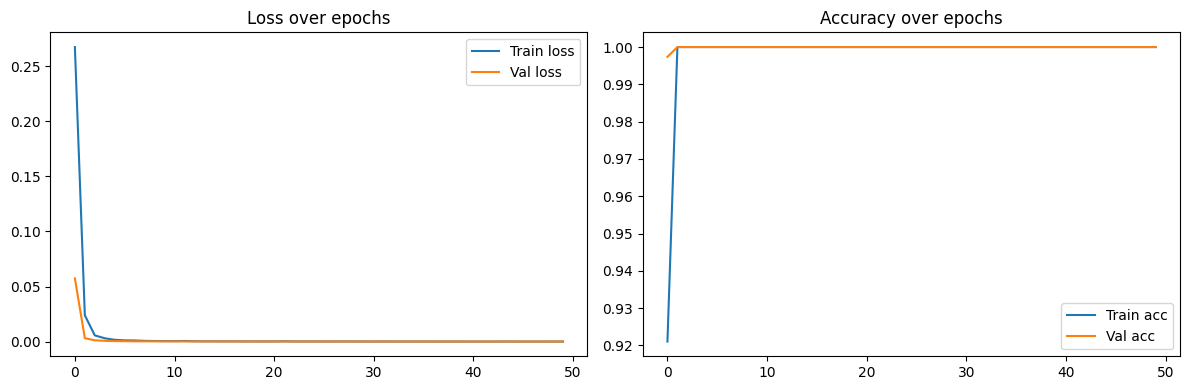

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred      = (y_pred_prob > 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

print('=== Confusion Matrix ===')
cm = confusion_matrix(y_test, y_pred)
print(cm)
print('Rows = actual class, Columns = predicted class')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'],         label='Train loss')
ax1.plot(history.history['val_loss'],     label='Val loss')
ax1.set_title('Loss over epochs'); ax1.legend()
ax2.plot(history.history['accuracy'],     label='Train acc')
ax2.plot(history.history['val_accuracy'], label='Val acc')
ax2.set_title('Accuracy over epochs'); ax2.legend()
plt.tight_layout()
plt.show()

## Step 6 — Export

In [7]:
import tf2onnx, shutil

model.save('pushup_model.keras')
print('Exported: pushup_model.keras')

scaler_params = {'mean': scaler.mean_.tolist(), 'scale': scaler.scale_.tolist()}
with open('pushup_model_scaler.json', 'w') as f:
    json.dump(scaler_params, f)
print('Exported: pushup_model_scaler.json')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open('pushup_model.tflite', 'wb') as f:
    f.write(tflite_model)
print('Exported: pushup_model.tflite')

import subprocess, sys
model.export('onnx_tmp')
result = subprocess.run([
    sys.executable, '-m', 'tf2onnx.convert',
    '--saved-model', 'onnx_tmp',
    '--output', 'pushup_model.onnx',
    '--opset', '13',
], capture_output=True, text=True)
shutil.rmtree('onnx_tmp')
if result.returncode != 0:
    print('ONNX error:', result.stderr)
else:
    print('Exported: pushup_model.onnx')

Exported: pushup_model.keras
Exported: pushup_model_scaler.json
INFO:tensorflow:Assets written to: C:\Users\gusta\AppData\Local\Temp\tmpo3i8lx9p\assets


INFO:tensorflow:Assets written to: C:\Users\gusta\AppData\Local\Temp\tmpo3i8lx9p\assets


Saved artifact at 'C:\Users\gusta\AppData\Local\Temp\tmpo3i8lx9p'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 21), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2028551978064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551977872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551977680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported: pushup_model.tflite
INFO:tensorflow:Assets written to: onnx_tmp\assets


INFO:tensorflow:Assets written to: onnx_tmp\assets


Saved artifact at 'onnx_tmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 21), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2028551978064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551977872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551977680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2028551978640: TensorSpec(shape=(), dtype=tf.resource, name=None)
Exported: pushup_model.onnx


## Step 7 — Live inference

In [8]:
try:
    import tflite_runtime.interpreter as _tflite
    Interpreter = _tflite.Interpreter
except ImportError:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter

from collections import deque

THRESHOLD    = 0.5
frame_buffer = deque(maxlen=SEQUENCE_LENGTH)

# TFLite interpreter — much faster than model.predict() in a live loop
tflite_interp = Interpreter(model_path='pushup_model.tflite')
tflite_interp.allocate_tensors()
inp_details  = tflite_interp.get_input_details()
out_details  = tflite_interp.get_output_details()

def predict_tflite(seq_scaled):
    tflite_interp.set_tensor(inp_details[0]['index'],
                             seq_scaled[np.newaxis, ...].astype(np.float32))
    tflite_interp.invoke()
    return float(tflite_interp.get_tensor(out_details[0]['index'])[0][0])


base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.VIDEO,
)

cap          = cv2.VideoCapture(0)
pushup_count = 0
in_down      = False
fps_live     = cap.get(cv2.CAP_PROP_FPS) or 30.0
ms_per_frame = 1000.0 / fps_live
timestamp_ms = 0

with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        timestamp_ms += int(ms_per_frame)
        rgb      = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result   = landmarker.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            label, features, avg_angle = extract_features(result.pose_landmarks[0])
            if features is not None:
                frame_buffer.append(features)

            if len(frame_buffer) == SEQUENCE_LENGTH:
                seq        = np.array(list(frame_buffer), dtype=np.float32)
                seq_scaled = scaler.transform(seq)
                prob       = predict_tflite(seq_scaled)

                is_down = prob > THRESHOLD
                if is_down and not in_down:
                    in_down = True
                elif not is_down and in_down:
                    pushup_count += 1
                    in_down = False

                state = f'DOWN {prob:.2f}' if is_down else f'UP {1-prob:.2f}'
                color = (0, 255, 255) if is_down else (0, 255, 0)
                angle_txt = f'  Angle:{avg_angle:.0f}' if avg_angle else ''
                cv2.putText(frame, f'{state}{angle_txt}  Reps:{pushup_count}',
                            (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)

        cv2.imshow('Push-up Detector (LSTM)', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


C:\Users\gusta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


RuntimeError: Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 1 (FlexTensorListReserve) failed to prepare.